[2026-06-24 17:39:53] [info     ] 计算因子，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-06-24 17:39:55] [info     ] 读取因子库，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-06-24 17:39:56] [warning  ] bigalpha_eval._latest version='v1' (use ._latest for dev only, not for prod)
[2026-06-24 17:39:59] [info     ] bigalpha_eval.v1 开始运行 ..
[2026-06-24 17:39:59] [info     ] 合并后时间范围: 2024-01-02 至 2024-12-31
[2026-06-24 17:39:59] [info     ] ========== 数据检查 ==========
[2026-06-24 17:39:59] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset_lf', 'current_

时段,IC
2024-01-15~2024-02-08,0.0134
2024-09-24~2024-10-08,-0.0003

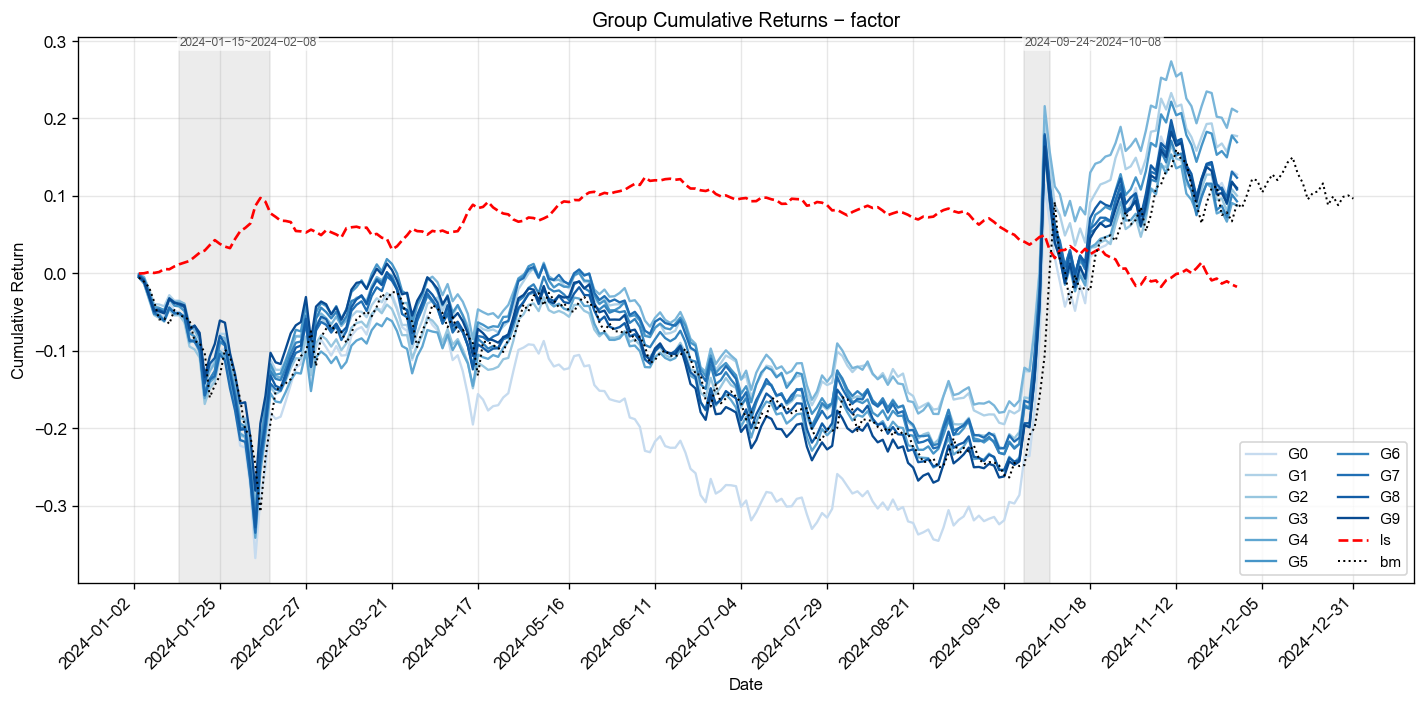
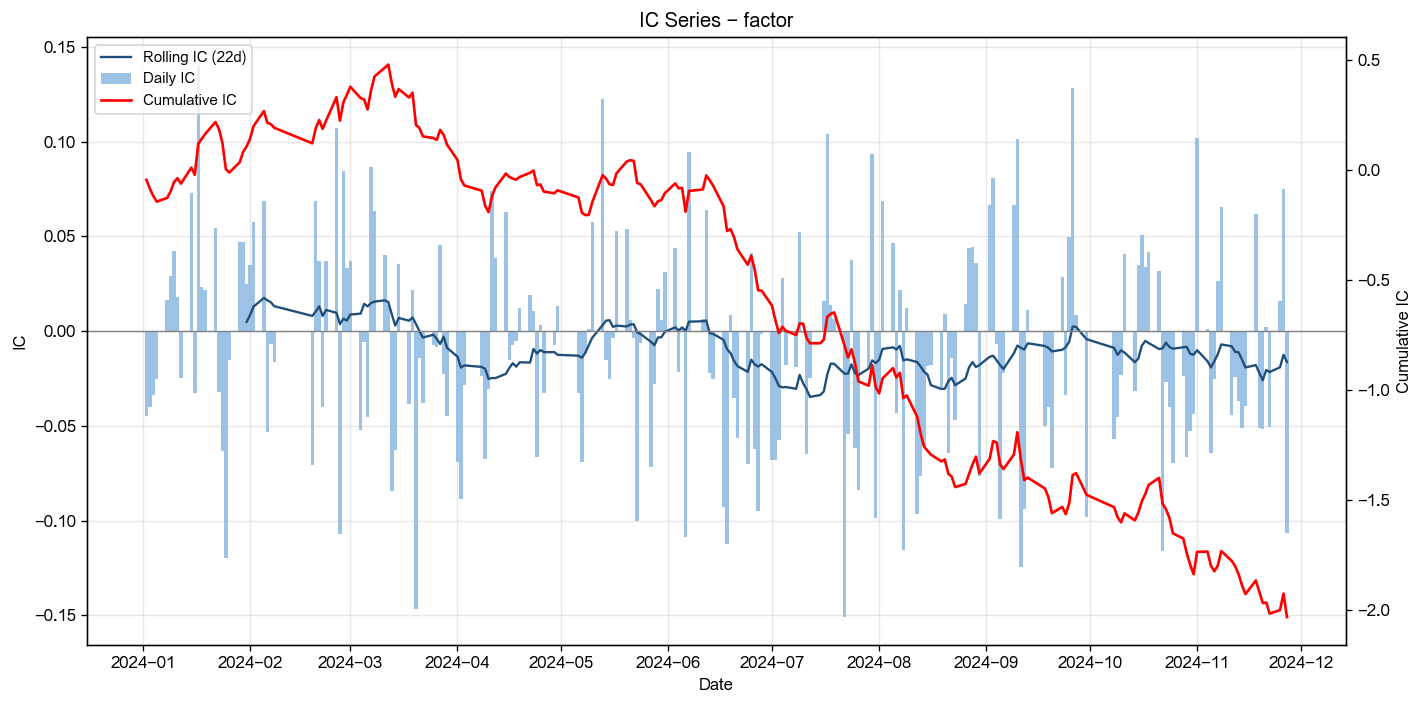
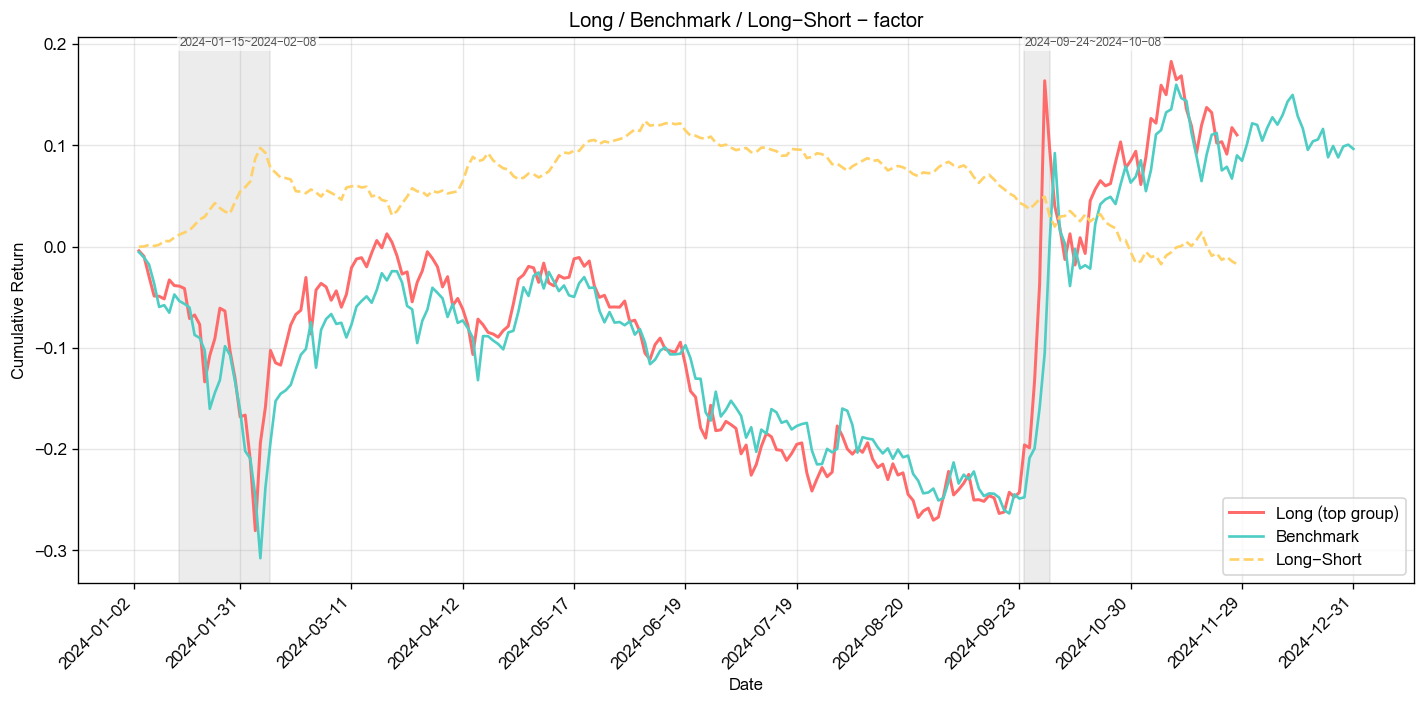
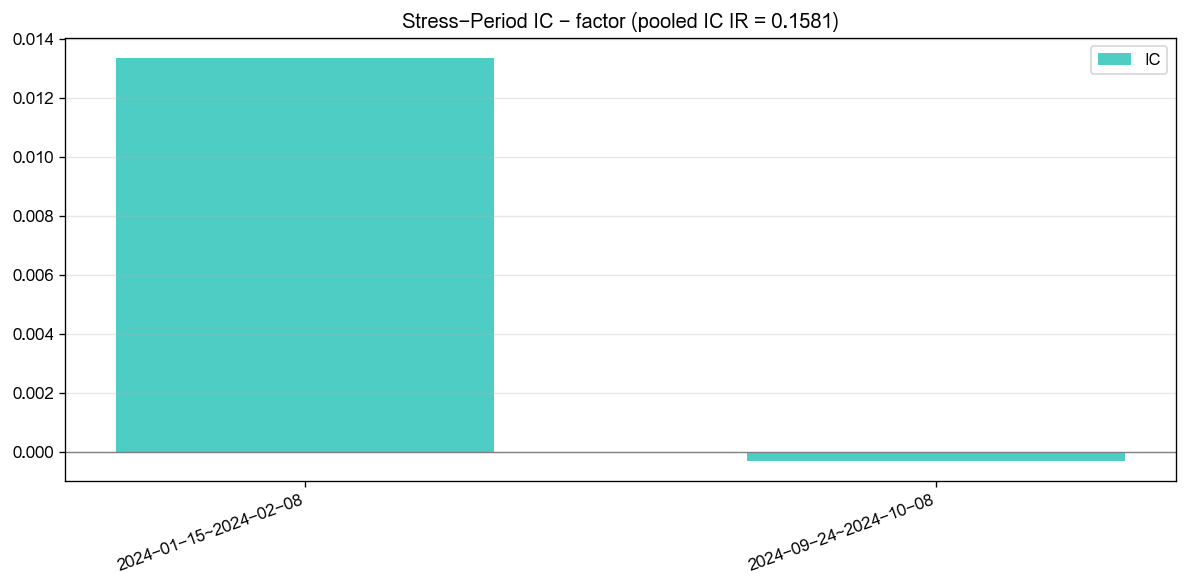
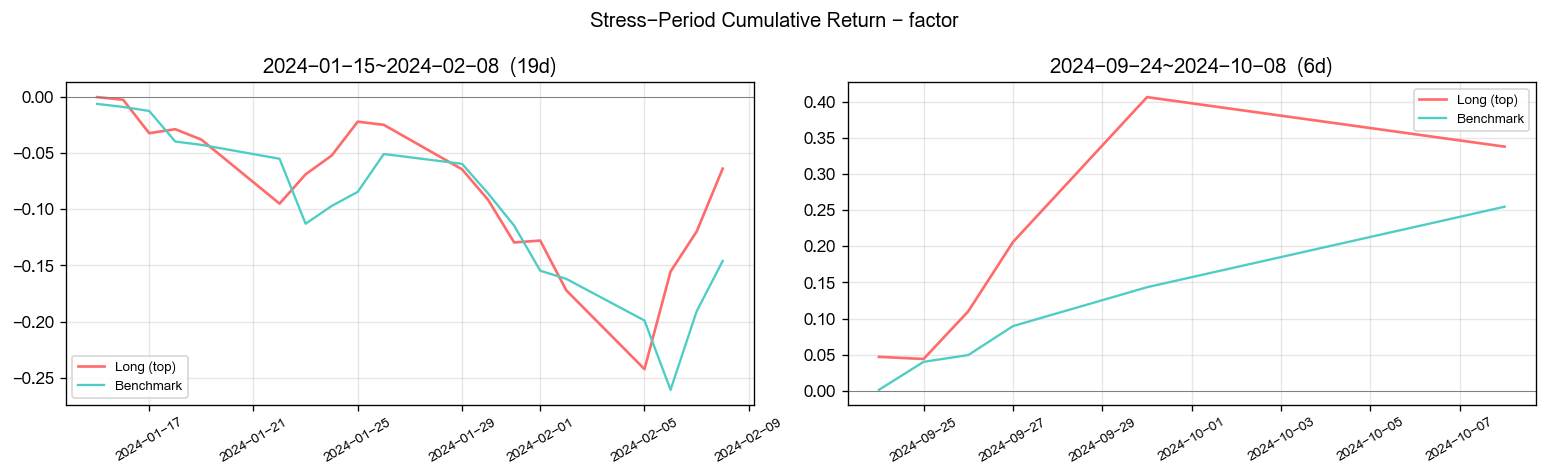

[2026-06-24 17:40:08] [info     ] ========== 因子池回归 ==========
[2026-06-24 17:40:09] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-06-24 17:40:09] [info     ] 获取收益率数据, 耗时: 0.9291 秒
[2026-06-24 17:40:09] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.0802 秒
[2026-06-24 17:40:09] [info     ] 统计 回归结果, 耗时: 0.0156 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9009,0.0453,0.0238,1.0000
2,factor,1.8764,0.0180,0.0096,1.0000
3,amount,1.7421,0.0187,0.0107,1.0000
4,netflow_amount_rate_main,1.5372,0.0100,0.0065,1.0000
5,netflow_amount_main,1.5103,0.0251,0.0166,1.0000
6,gross_profit_rate_ttm,1.4825,0.0071,0.0048,1.0000
7,ps_ttm,1.4570,0.0040,0.0027,0.9000
8,pb,1.4491,0.0100,0.0069,0.9000
9,roe_avg_ttm,1.4258,0.0239,0.0167,0.9000
10,net_profit_rate_ttm,1.4110,0.0037,0.0026,0.8000

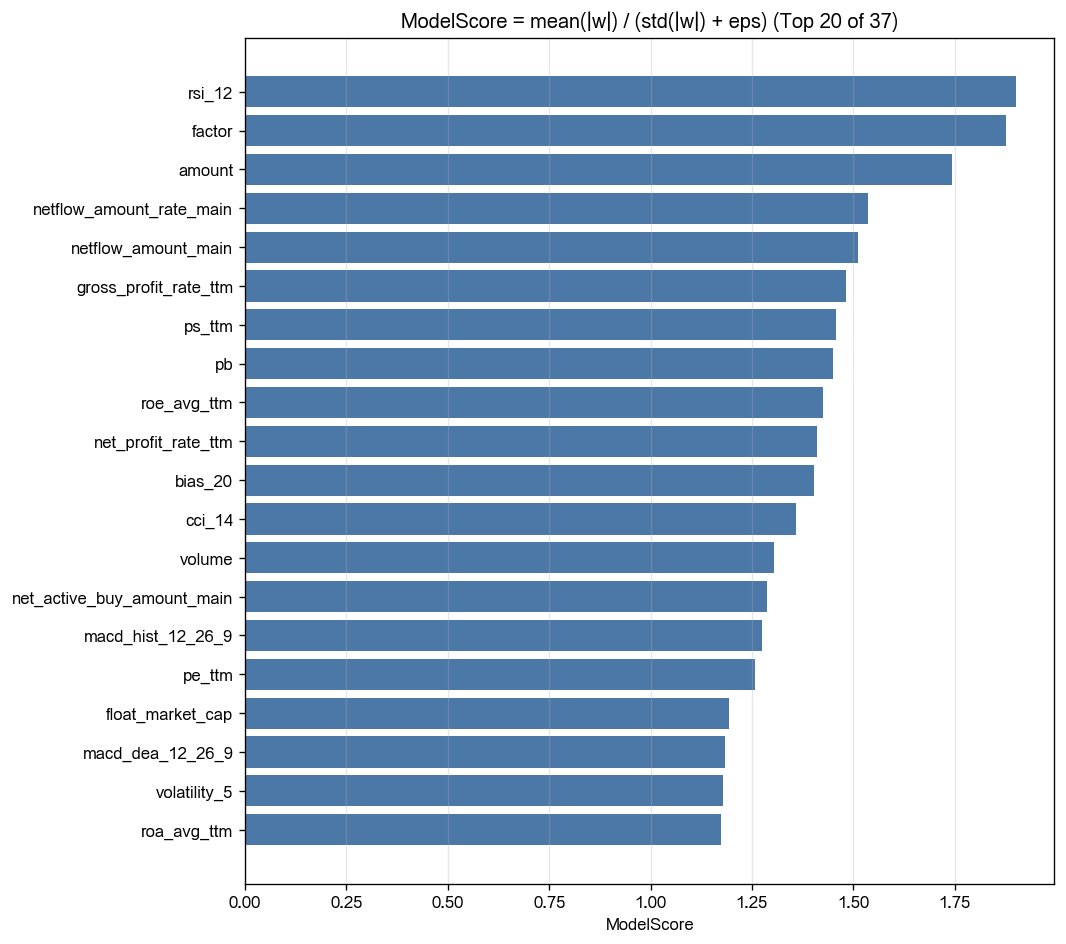
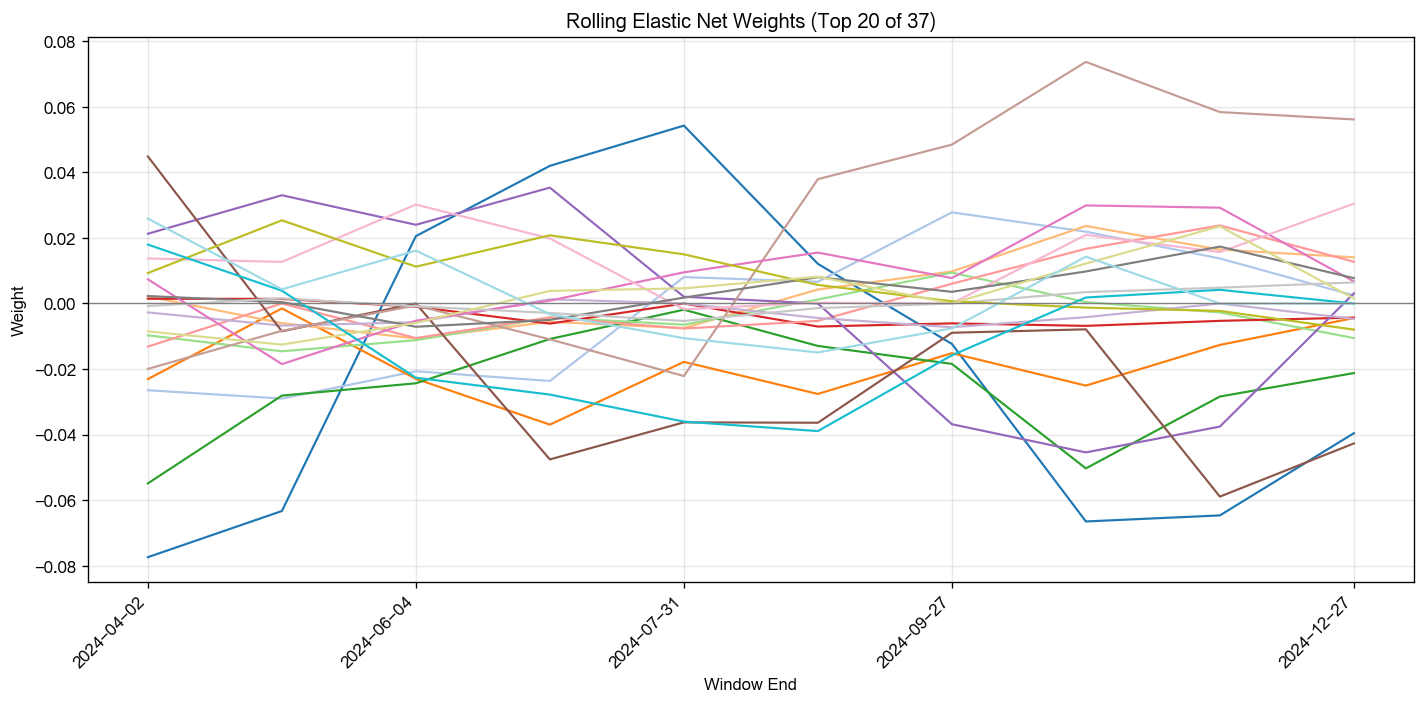
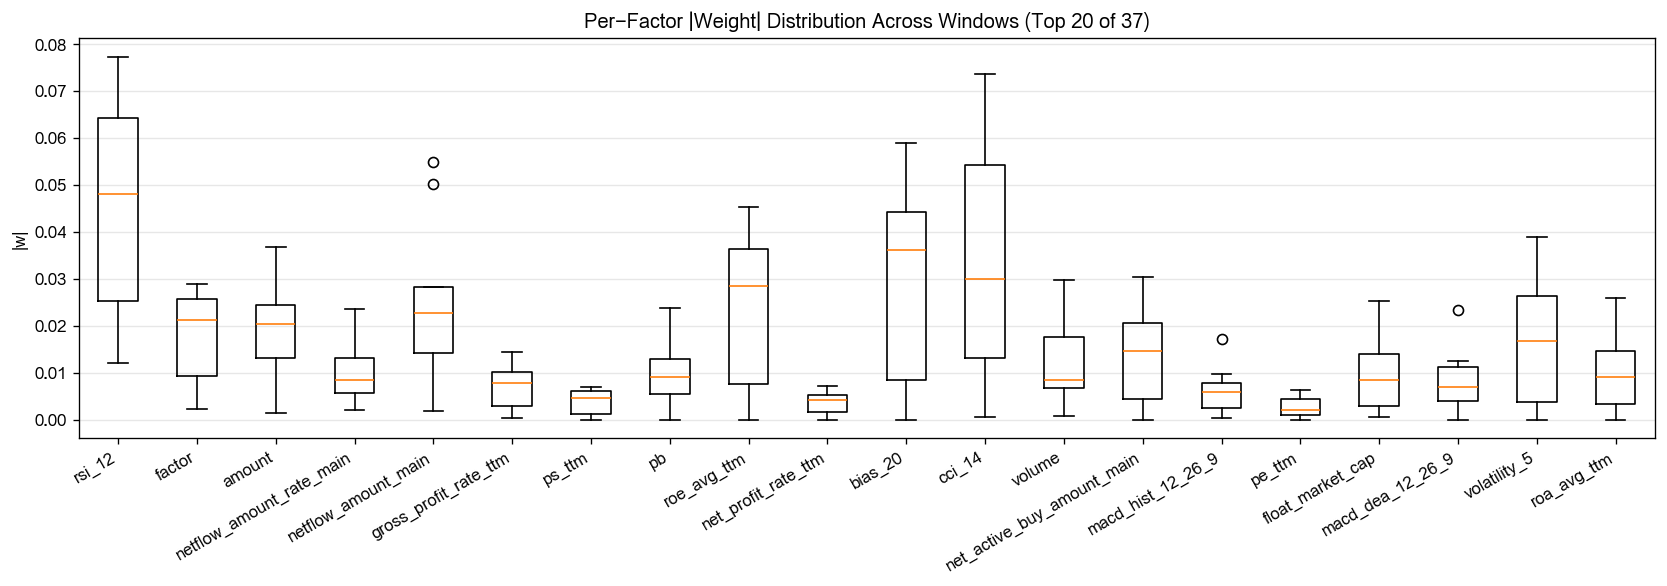
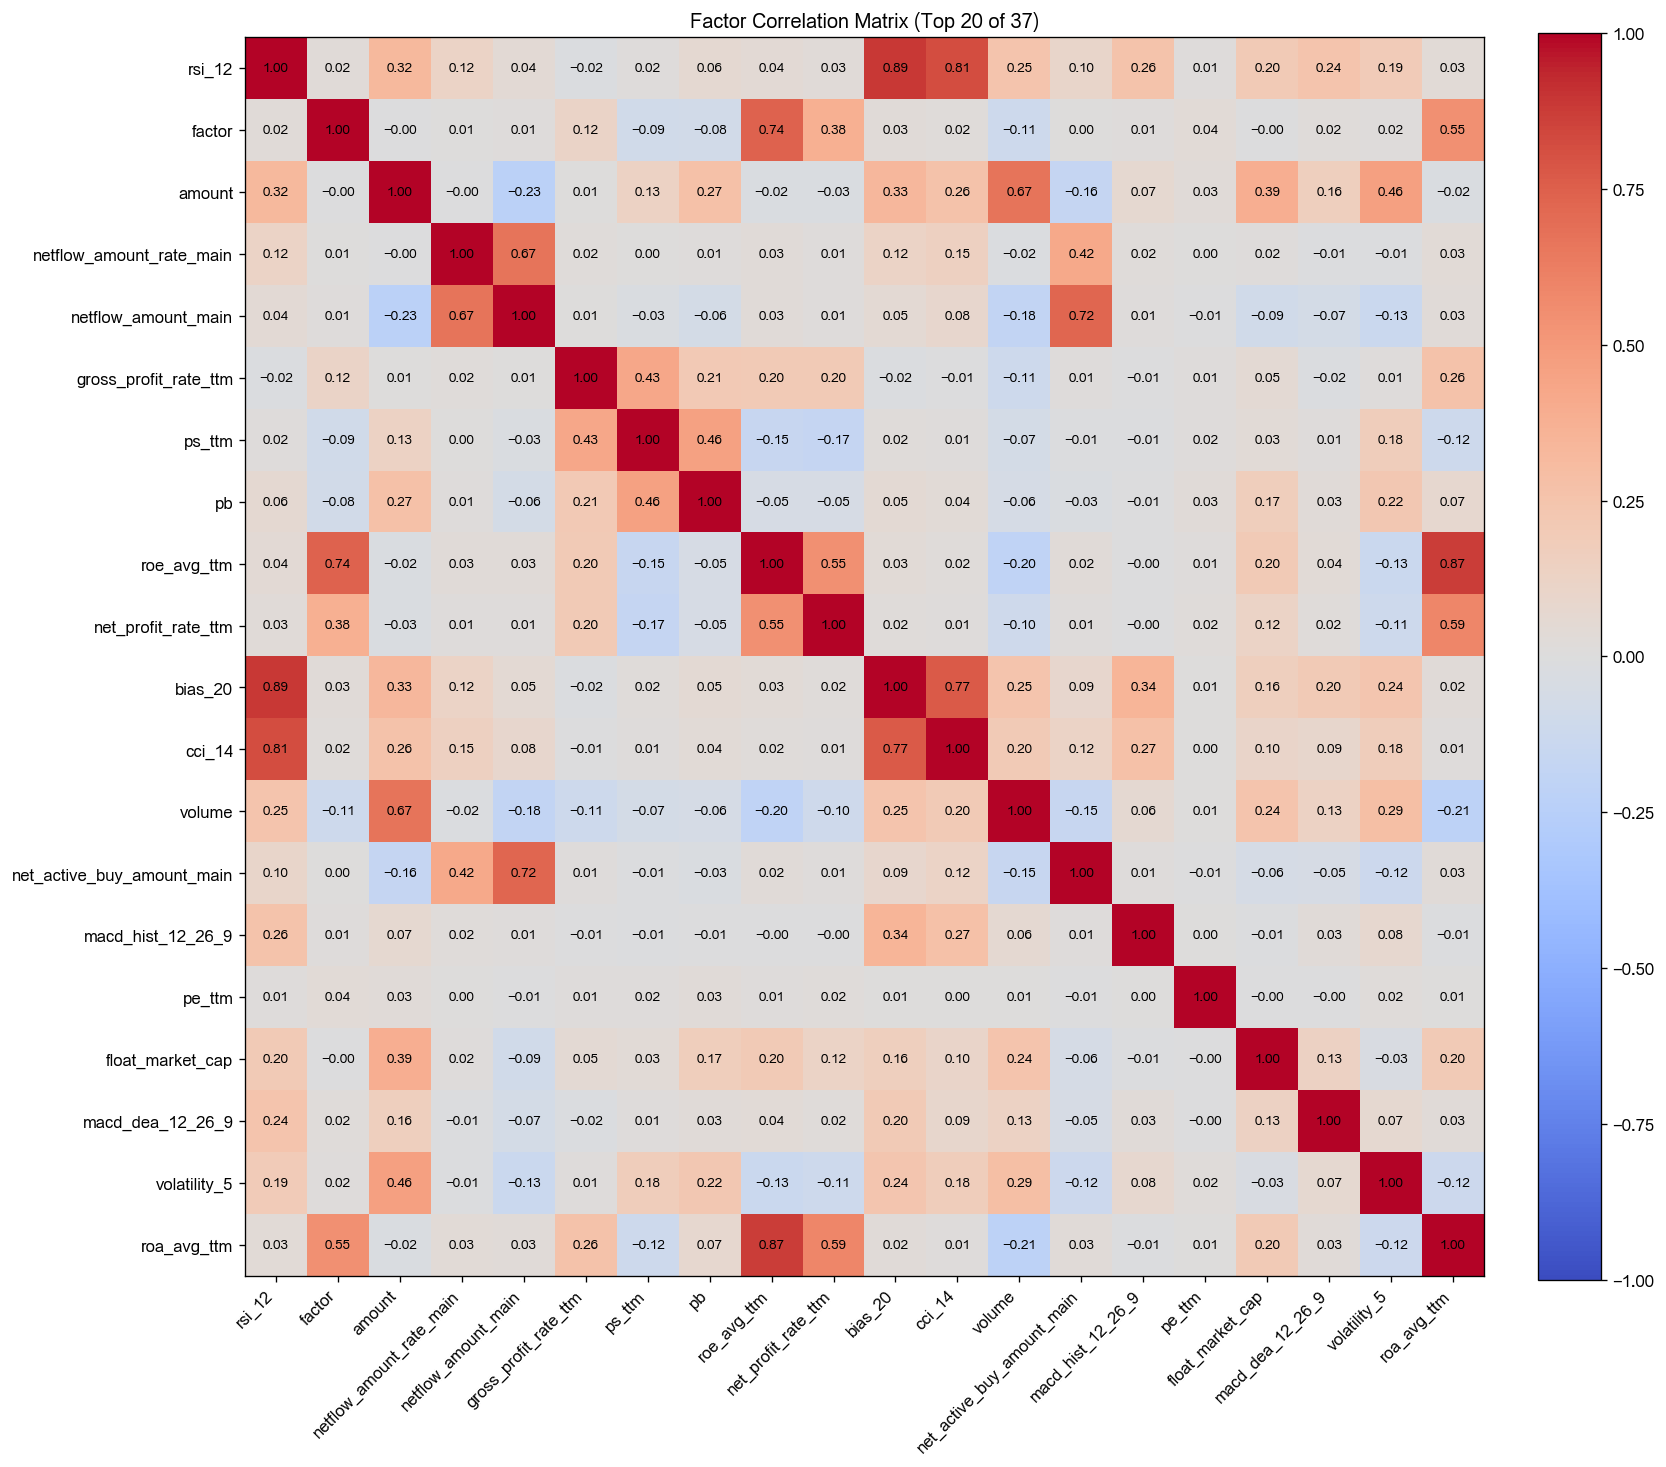

[2026-06-24 17:40:12] [warning  ] 返回的Outputs实例(size=35258167) 大于 64K, 将不会被缓存
[2026-06-24 17:40:12] [info     ] bigalpha_eval.v1 运行完成 [13.392s].


In [1]:
def main(datasources, start_date, end_date):
    """
    因子构建主函数

    评测时平台会自动替换 datasources / start_date / end_date 三个入参并调用本函数

    参数:
        datasources (dict): 数据源表名映射 {逻辑名: 物理表名}。一个因子可同时用到多张表，
                            通过逻辑名取出该阶段实际的物理表名，平台会在公榜/私榜自动切换。
                            当前可用逻辑名:
                                "bar1m"     -> 分钟 K 线表
                                "financial" -> 财务数据表
        start_date (str): 开始时间
        end_date (str):   结束时间

    返回:
        pd.DataFrame: 因子数据，须包含三列 ['date', 'instrument', 'factor']，且不含 inf
    """
    import pandas as pd
    import dai

    # 从映射里取出本阶段实际的物理表名（切勿在 SQL 里硬编码表名，否则公榜/私榜无法切换）
    financial_table = datasources["financial"]

    # 由于财务数据的date是公告日的，非日频数据，因此建议向前取1年的数据
    LOOKBACK_DAYS = 365
    query_start_date = pd.to_datetime(start_date) - pd.Timedelta(days=LOOKBACK_DAYS)

    # ===== 计算 roe 因子 =====
    # ROE_TTM = 归母净利润 TTM / 归母净资产 LF
    sql = f"""
    WITH cte_ttm AS (
        SELECT date, instrument, net_profit_to_parent_shareholders as np_ttm
        FROM {financial_table}
        WHERE category='ttm'
        AND shift=0
    ),
    cte_lf AS (
        SELECT date, instrument, total_equity_to_parent_shareholders as equity_lf
        FROM {financial_table}
        WHERE category='lf'
        AND shift=0
    )
    SELECT date, instrument, np_ttm / equity_lf as factor
    FROM cte_ttm
    PRUNE JOIN cte_lf USING (date, instrument)
    """
    financial_df = dai.query(sql, filters={'date': [query_start_date, end_date]}).df()

    # ===== 将财务因子转化为日频 =====
    # 由于财务数据存在非交易日发布的情况，因此先转后为日频数据再进行填充
    def fill_natural_dates(df: pd.DataFrame, sd: str, ed: str) -> pd.DataFrame:
        """将公告日的财务数据转换为自然日"""
        natural_dates = pd.date_range(start=sd, end=ed)
        df.set_index('date', inplace=True)
        def reindex_and_fill(group_df):
            """对每个 instrument 分组进行重新索引和条件填充的辅助函数"""
            reindexed_df = group_df.reindex(natural_dates)
            instrument_name = group_df.name
            filled_df = reindexed_df.ffill()
            filled_df['instrument'] = instrument_name
            return filled_df
        df_filled = df.groupby('instrument', group_keys=False).apply(reindex_and_fill)
        df_filled = (
            df_filled.reset_index()  # 将日期索引转为列
            .rename(columns={'index': 'date'}) # 确保日期列名为 'trade_dt'
            .dropna(subset=['instrument']) # 清理可能残留的 instrument 为 NaN 的行
        )
        return df_filled
    daily_df = fill_natural_dates(financial_df, query_start_date, end_date)

    # ===== 对齐股票池 =====
    # 数据源保留了 2019 年至今所有成分股的数据以便计算时序因子，
    # 因此需与中证 1000 成分股做内连接，只保留当日属于成分股的标的
    # bigalpha_2026_instruments 已经收录了2019年以来的所有数据，不用替换
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]},
    ).df()
    df = pd.merge(daily_df, stk_pool, how='right', on=['date', 'instrument'])

    df
    return df


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    # 本地自测时自行构造数据源映射（评测时由平台注入，逻辑名固定为 "bar1m"/"financial"）
    datasources = {'financial': 'bigalpha_2026_financial',}
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    # 计算因子
    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    # 读取平台因子库用于回归评估，您可以换成自己的因子库
    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    # 评估系统：
    # process_pools=False 表示不对因子库再做预处理（bigalpha_2026_factorlib 已处理过）
    # show=True 表示画出评估图表
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
